# 03. Train a Random Forest Audio Classifier

This notebook trains the first machine learning model for the project.

We will:

1. Load the extracted audio features
2. Use ESC-50 folds 1 to 4 for training
3. Use fold 5 as unseen test data
4. Train a Random Forest classifier
5. Measure accuracy and class-wise performance
6. Plot a confusion matrix
7. Save the trained model


In [1]:
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    classification_report,
    confusion_matrix,
)


## 1. Locate the project files


In [2]:
PROJECT_ROOT = Path.cwd().resolve()

if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

FEATURES_PATH = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "audio_features_all_50.csv"
)
MODELS_DIR = PROJECT_ROOT / "models"
MODEL_PATH = MODELS_DIR / "random_forest_esc50_classifier.joblib"

if not FEATURES_PATH.exists():
    raise FileNotFoundError(
        "The feature file was not found at:\n"
        f"{FEATURES_PATH}\n\n"
        "Run 02_feature_extraction.ipynb first."
    )

MODELS_DIR.mkdir(parents=True, exist_ok=True)

print(f"Feature file: {FEATURES_PATH}")
print(f"Model output: {MODEL_PATH}")


Feature file: C:\Users\BASIL THOMAS\Desktop\audio-ml-classifier\data\processed\audio_features_all_50.csv
Model output: C:\Users\BASIL THOMAS\Desktop\audio-ml-classifier\models\random_forest_esc50_classifier.joblib


## 2. Load the feature dataset


In [3]:
features_df = pd.read_csv(FEATURES_PATH)

print(f"Dataset shape: {features_df.shape}")
print()
print("Class distribution:")
print(features_df["category"].value_counts().sort_index())

features_df.head()


Dataset shape: (2000, 35)

Class distribution:
category
airplane            40
breathing           40
brushing_teeth      40
can_opening         40
car_horn            40
cat                 40
chainsaw            40
chirping_birds      40
church_bells        40
clapping            40
clock_alarm         40
clock_tick          40
coughing            40
cow                 40
crackling_fire      40
crickets            40
crow                40
crying_baby         40
dog                 40
door_wood_creaks    40
door_wood_knock     40
drinking_sipping    40
engine              40
fireworks           40
footsteps           40
frog                40
glass_breaking      40
hand_saw            40
helicopter          40
hen                 40
insects             40
keyboard_typing     40
laughing            40
mouse_click         40
pig                 40
pouring_water       40
rain                40
rooster             40
sea_waves           40
sheep               40
siren               40
s

,filename,fold,target,category,mfcc_1_mean,mfcc_1_std,mfcc_2_mean,mfcc_2_std,mfcc_3_mean,mfcc_3_std,...,mfcc_11_std,mfcc_12_mean,mfcc_12_std,mfcc_13_mean,mfcc_13_std,zero_crossing_rate_mean,spectral_centroid_mean,spectral_bandwidth_mean,spectral_rolloff_mean,rms_energy_mean
0,1-11687-A-47.wav,1,47,airplane,-68.407730,117.749306,78.223381,34.157211,4.756897,11.442808,...,6.216324,10.396147,6.988348,-1.341286,5.133182,0.137854,2674.141151,2627.421648,5795.322673,0.183195
1,1-24796-A-47.wav,1,47,airplane,34.127151,72.993164,65.127335,22.012934,-12.650159,12.633339,...,4.449233,6.808112,5.648208,-0.187221,4.383595,0.218474,3223.180663,2617.969055,6310.125732,0.240778
2,1-36929-A-47.wav,1,47,airplane,-129.324219,14.076441,189.748535,9.874305,-44.204517,7.323853,...,4.013986,-4.395473,4.460861,-4.997627,4.397005,0.049714,1092.937486,1291.591579,2787.901815,0.272882
3,1-43807-A-47.wav,1,47,airplane,-166.561600,33.534286,216.454849,19.463509,-29.961597,10.657622,...,5.545503,-11.170605,7.190721,-5.914539,4.404808,0.027344,751.389041,1034.102682,1423.334757,0.183570
4,1-43807-B-47.wav,1,47,airplane,-327.550720,17.159882,241.709198,12.252018,13.818749,11.284963,...,5.151096,4.208405,4.476974,2.099718,4.411973,0.019050,428.805582,746.835156,726.346842,0.074196


## 3. Separate input features and labels

The model should receive only numerical audio features.

These columns are not used as model inputs:

- `filename`
- `fold`
- `target`
- `category`


In [4]:
metadata_columns = [
    "filename",
    "fold",
    "target",
    "category",
]

feature_columns = [
    column
    for column in features_df.columns
    if column not in metadata_columns
]

X = features_df[feature_columns]
y = features_df["category"]

print(f"Number of recordings: {len(X)}")
print(f"Number of input features: {len(feature_columns)}")
print(f"Classes: {sorted(y.unique())}")


Number of recordings: 2000
Number of input features: 31
Classes: ['airplane', 'breathing', 'brushing_teeth', 'can_opening', 'car_horn', 'cat', 'chainsaw', 'chirping_birds', 'church_bells', 'clapping', 'clock_alarm', 'clock_tick', 'coughing', 'cow', 'crackling_fire', 'crickets', 'crow', 'crying_baby', 'dog', 'door_wood_creaks', 'door_wood_knock', 'drinking_sipping', 'engine', 'fireworks', 'footsteps', 'frog', 'glass_breaking', 'hand_saw', 'helicopter', 'hen', 'insects', 'keyboard_typing', 'laughing', 'mouse_click', 'pig', 'pouring_water', 'rain', 'rooster', 'sea_waves', 'sheep', 'siren', 'sneezing', 'snoring', 'thunderstorm', 'toilet_flush', 'train', 'vacuum_cleaner', 'washing_machine', 'water_drops', 'wind']


## 4. Create training and test datasets

ESC-50 already provides five official folds.

We use:

- Folds 1, 2, 3, and 4 for training
- Fold 5 for testing

This avoids mixing recordings from the same predefined evaluation group.


In [5]:
train_mask = features_df["fold"].isin([1, 2, 3, 4])
test_mask = features_df["fold"] == 5

X_train = X.loc[train_mask]
X_test = X.loc[test_mask]

y_train = y.loc[train_mask]
y_test = y.loc[test_mask]

print(f"Training recordings: {len(X_train)}")
print(f"Test recordings: {len(X_test)}")
print()
print("Training class counts:")
print(y_train.value_counts().sort_index())
print()
print("Test class counts:")
print(y_test.value_counts().sort_index())


Training recordings: 1600
Test recordings: 400

Training class counts:
category
airplane            32
breathing           32
brushing_teeth      32
can_opening         32
car_horn            32
cat                 32
chainsaw            32
chirping_birds      32
church_bells        32
clapping            32
clock_alarm         32
clock_tick          32
coughing            32
cow                 32
crackling_fire      32
crickets            32
crow                32
crying_baby         32
dog                 32
door_wood_creaks    32
door_wood_knock     32
drinking_sipping    32
engine              32
fireworks           32
footsteps           32
frog                32
glass_breaking      32
hand_saw            32
helicopter          32
hen                 32
insects             32
keyboard_typing     32
laughing            32
mouse_click         32
pig                 32
pouring_water       32
rain                32
rooster             32
sea_waves           32
sheep               32


The expected split is:

- 160 training recordings
- 40 test recordings


## 5. Create and train the Random Forest model


In [6]:
model = RandomForestClassifier(
    n_estimators=500,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1,
)

model.fit(X_train, y_train)

print("Model training completed.")
print("Number of trained classes:", len(model.classes_))

Model training completed.
Number of trained classes: 50


## 6. Predict the classes of unseen recordings


In [7]:
y_pred = model.predict(X_test)

results_df = pd.DataFrame({
    "filename": features_df.loc[test_mask, "filename"].values,
    "actual_class": y_test.values,
    "predicted_class": y_pred,
})

results_df["correct"] = (
    results_df["actual_class"] == results_df["predicted_class"]
)

results_df.head(10)


,filename,actual_class,predicted_class,correct
0,5-215445-A-47.wav,airplane,wind,False
1,5-215447-A-47.wav,airplane,airplane,True
2,5-215449-A-47.wav,airplane,airplane,True
3,5-235956-A-47.wav,airplane,airplane,True
4,5-251957-A-47.wav,airplane,train,False
5,5-251962-A-47.wav,airplane,airplane,True
6,5-251963-A-47.wav,airplane,sea_waves,False
7,5-251971-A-47.wav,airplane,chainsaw,False
8,5-213293-A-23.wav,breathing,breathing,True
9,5-232816-A-23.wav,breathing,thunderstorm,False


## 7. Calculate test accuracy


In [8]:
accuracy = accuracy_score(y_test, y_pred)

print(f"Test accuracy: {accuracy:.4f}")
print(f"Test accuracy percentage: {accuracy * 100:.2f}%")
print(f"Correct predictions: {results_df['correct'].sum()}/{len(results_df)}")


Test accuracy: 0.4475
Test accuracy percentage: 44.75%
Correct predictions: 179/400


Because this is a small beginner dataset, the exact accuracy can vary across folds. The main goal is to build a complete and correctly evaluated machine learning pipeline.


## 8. Display precision, recall, and F1-score


In [9]:
print(
    classification_report(
        y_test,
        y_pred,
        digits=3,
        zero_division=0,
    )
)


                  precision    recall  f1-score   support

        airplane      0.571     0.500     0.533         8
       breathing      0.500     0.125     0.200         8
  brushing_teeth      0.714     0.625     0.667         8
     can_opening      0.400     0.250     0.308         8
        car_horn      0.750     0.375     0.500         8
             cat      0.714     0.625     0.667         8
        chainsaw      0.250     0.375     0.300         8
  chirping_birds      0.714     0.625     0.667         8
    church_bells      0.571     0.500     0.533         8
        clapping      0.167     0.125     0.143         8
     clock_alarm      0.857     0.750     0.800         8
      clock_tick      0.000     0.000     0.000         8
        coughing      0.300     0.375     0.333         8
             cow      0.750     0.375     0.500         8
  crackling_fire      0.800     0.500     0.615         8
        crickets      0.857     0.750     0.800         8
            c

Important evaluation terms:

- **Precision:** Of the recordings predicted as one class, how many were correct?
- **Recall:** Of the real recordings in one class, how many did the model find?
- **F1-score:** A balance between precision and recall.


## 9. Plot the confusion matrix


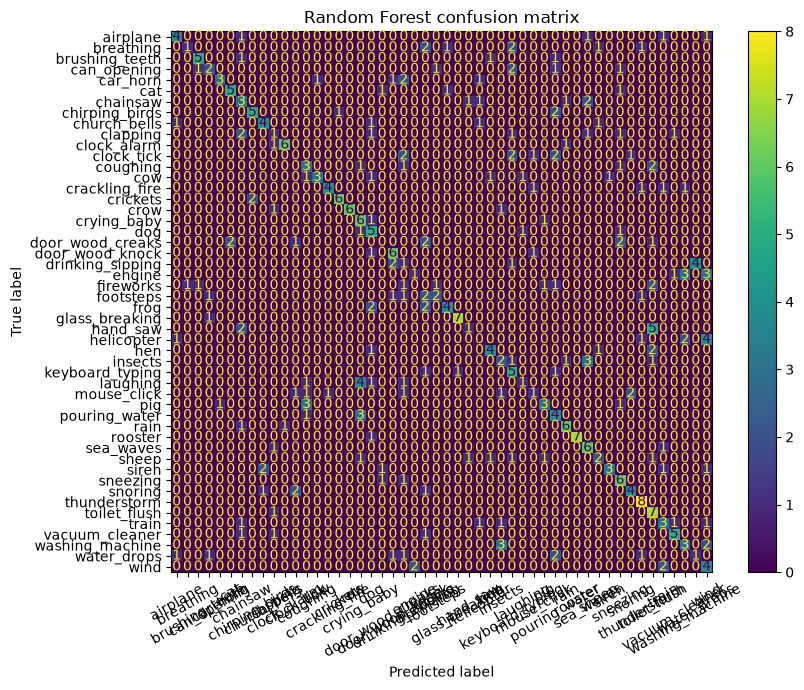

In [10]:
class_names = sorted(y.unique())

matrix = confusion_matrix(
    y_test,
    y_pred,
    labels=class_names,
)

display = ConfusionMatrixDisplay(
    confusion_matrix=matrix,
    display_labels=class_names,
)

fig, ax = plt.subplots(figsize=(9, 7))
display.plot(
    ax=ax,
    values_format="d",
    xticks_rotation=30,
)
ax.set_title("Random Forest confusion matrix")
plt.tight_layout()
plt.show()


The diagonal cells are correct predictions. Off-diagonal cells show which classes were confused with each other.


## 10. Inspect incorrect predictions


In [11]:
incorrect_predictions = results_df[
    ~results_df["correct"]
].reset_index(drop=True)

print(f"Incorrect predictions: {len(incorrect_predictions)}")
incorrect_predictions


Incorrect predictions: 221


,filename,actual_class,predicted_class,correct
0,5-215445-A-47.wav,airplane,wind,False
1,5-251957-A-47.wav,airplane,train,False
2,5-251963-A-47.wav,airplane,sea_waves,False
3,5-251971-A-47.wav,airplane,chainsaw,False
4,5-232816-A-23.wav,breathing,thunderstorm,False
...,...,...,...,...
216,5-262641-A-15.wav,water_drops,airplane,False
217,5-157204-A-16.wav,wind,engine,False
218,5-157204-B-16.wav,wind,engine,False
219,5-179496-A-16.wav,wind,train,False


## 11. Display the most important audio features


In [12]:
importance_df = pd.DataFrame({
    "feature": feature_columns,
    "importance": model.feature_importances_,
}).sort_values(
    "importance",
    ascending=False,
).reset_index(drop=True)

importance_df.head(15)


,feature,importance
0,mfcc_2_mean,0.046487
1,mfcc_1_std,0.044994
2,mfcc_1_mean,0.044075
3,mfcc_3_mean,0.041962
4,rms_energy_mean,0.039442
5,mfcc_2_std,0.037779
6,spectral_bandwidth_mean,0.035765
7,mfcc_4_mean,0.035406
8,spectral_centroid_mean,0.035056
9,mfcc_3_std,0.034094


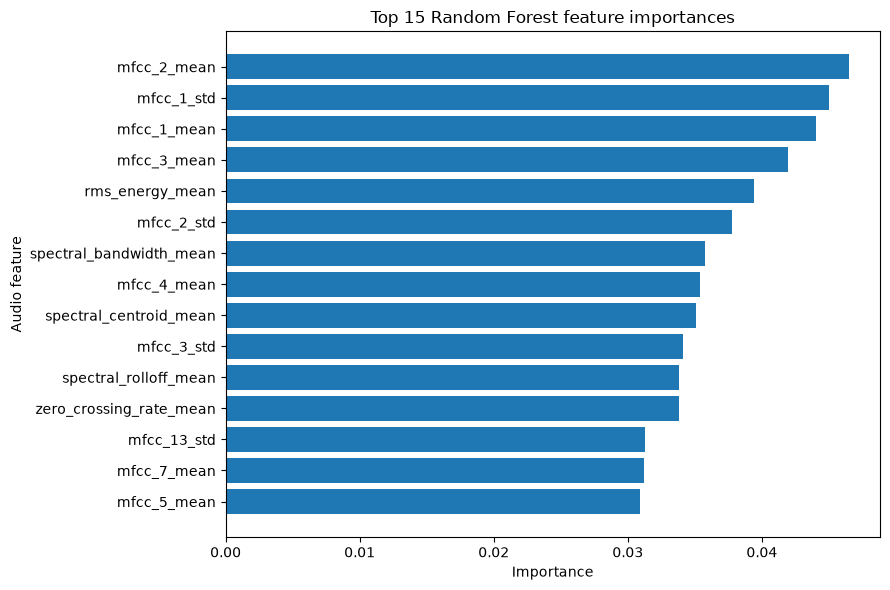

In [13]:
top_features = importance_df.head(15).sort_values(
    "importance",
    ascending=True,
)

plt.figure(figsize=(9, 6))
plt.barh(
    top_features["feature"],
    top_features["importance"],
)
plt.title("Top 15 Random Forest feature importances")
plt.xlabel("Importance")
plt.ylabel("Audio feature")
plt.tight_layout()
plt.show()


Feature importance estimates which extracted measurements were most useful to the Random Forest. It does not prove that one feature directly causes a prediction.


## 12. Save the trained model


In [14]:
model_bundle = {
    "model": model,
    "feature_columns": feature_columns,
    "classes": class_names,
    "test_fold": 5,
    "test_accuracy": accuracy,
}

joblib.dump(
    model_bundle,
    MODEL_PATH,
)

print(f"Saved model to:\n{MODEL_PATH}")


Saved model to:
C:\Users\BASIL THOMAS\Desktop\audio-ml-classifier\models\random_forest_esc50_classifier.joblib


## 13. Verify that the saved model can be loaded


In [15]:
loaded_bundle = joblib.load(MODEL_PATH)
loaded_model = loaded_bundle["model"]

verification_predictions = loaded_model.predict(X_test)

same_predictions = (
    verification_predictions == y_pred
).all()

print(f"Saved model loaded successfully: {same_predictions}")
print(f"Saved classes: {loaded_bundle['classes']}")
print(
    "Saved test accuracy: "
    f"{loaded_bundle['test_accuracy'] * 100:.2f}%"
)


Saved model loaded successfully: True
Saved classes: ['airplane', 'breathing', 'brushing_teeth', 'can_opening', 'car_horn', 'cat', 'chainsaw', 'chirping_birds', 'church_bells', 'clapping', 'clock_alarm', 'clock_tick', 'coughing', 'cow', 'crackling_fire', 'crickets', 'crow', 'crying_baby', 'dog', 'door_wood_creaks', 'door_wood_knock', 'drinking_sipping', 'engine', 'fireworks', 'footsteps', 'frog', 'glass_breaking', 'hand_saw', 'helicopter', 'hen', 'insects', 'keyboard_typing', 'laughing', 'mouse_click', 'pig', 'pouring_water', 'rain', 'rooster', 'sea_waves', 'sheep', 'siren', 'sneezing', 'snoring', 'thunderstorm', 'toilet_flush', 'train', 'vacuum_cleaner', 'washing_machine', 'water_drops', 'wind']
Saved test accuracy: 44.75%


## Third milestone complete

You have now built a complete basic audio machine learning pipeline:

1. Loaded environmental sound recordings
2. Visualized waveforms and spectrograms
3. Extracted numerical audio features
4. Trained a Random Forest classifier
5. Evaluated it on unseen recordings
6. Saved the trained model

The next stage will create a prediction script where you can provide a new WAV file and receive the predicted sound class.
